In [1]:
from mmpose.apis import MMPoseInferencer
from datetime import datetime
import subprocess
import os

while os.getcwd().split('/')[-1] != 'mmpose-synthetic-tune':
    os.chdir('..')

In [2]:
class MMPoseModelCoach:
    command = 'python'
    script = 'mmpose/tools/train.py'
    
    detector_model = {  #rtmdet
        "det_model": 'mmdetection/configs/rtmdet/rtmdet_l_swin_b_p6_4xb16-100e_coco.py',
        "det_weights": 'checkpoints/rtmdet_l_swin_b_p6_4xb16-100e_coco-a1486b6f.pth'
    }

    def __init__(self, config, resume=True, work_dir=None, notes=''):
        current_time = datetime.now().strftime('%Y-%m-%d_%H-%M-%S')

        self.config = config
        self.config_path = f'dataset-coco/custom-configs/{self.config}'
        self.resume = '--resume' if resume == True else ''
        if work_dir is not None:
            self.work_dir = work_dir
        else:
            self.work_dir = f'models/_train-{current_time}-{notes}'

        self.args = [
            self.command,
            self.script,
            self.config_path,
            '--work-dir',
            self.work_dir,
            self.resume,
        ]

    def train(self):
        subprocess.run(self.args)

    def visualize_results(self, model_ckpt, vis_input, radius=3, thickness=1):
        poser_model = {
            "pose2d": f'{self.work_dir}/{self.config}',
            "pose2d_weights": f'{self.work_dir}/{model_ckpt}',
        }

        inferencer = MMPoseInferencer(**poser_model, **self.detector_model, device='cuda:0')

        input_path = vis_input
        output_path = f'{self.work_dir}/vis_results'

        result_generator = inferencer(
            input_path,
            radius=radius,
            thickness=thickness,
            vis_out_dir=output_path,
            draw_heatmap=True,
            det_cat_ids=5
        )

        results = [res for res in result_generator]


### Train and Visualize

In [9]:
base_hrnet = MMPoseModelCoach(
    config='cow20kp-base-ap10k-hrnet.py',
    notes='base-hrnet-ap10k-new-labels'
)

base_hrnet.train()

04/22 18:36:14 - mmengine - INFO - 
------------------------------------------------------------
System environment:
    sys.platform: linux
    Python: 3.9.19 (main, Apr  6 2024, 17:57:55) [GCC 11.4.0]
    CUDA available: True
    MUSA available: False
    numpy_random_seed: 1334369831
    GPU 0: NVIDIA GeForce RTX 4070
    CUDA_HOME: /usr/local/cuda
    NVCC: Cuda compilation tools, release 11.8, V11.8.89
    GCC: x86_64-linux-gnu-gcc (Ubuntu 11.4.0-1ubuntu1~22.04) 11.4.0
    PyTorch: 2.2.1+cu118
    PyTorch compiling details: PyTorch built with:
  - GCC 9.3
  - C++ Version: 201703
  - Intel(R) oneAPI Math Kernel Library Version 2022.2-Product Build 20220804 for Intel(R) 64 architecture applications
  - Intel(R) MKL-DNN v3.3.2 (Git Hash 2dc95a2ad0841e29db8b22fbccaf3e5da7992b01)
  - OpenMP 201511 (a.k.a. OpenMP 4.5)
  - LAPACK is enabled (usually provided by MKL)
  - NNPACK is enabled
  - CPU capability usage: AVX2
  - CUDA Runtime 11.8
  - NVCC architecture flags: -gencode;arch=compu

In [12]:
base_hrnet.visualize_results(
    model_ckpt='epoch_210.pth',
    vis_input='dataset-coco/data/test-footage/cow.png'
)

Loads checkpoint by local backend from path: models/_train-2024-04-22_18-36-12-base-hrnet-ap10k-new-labels/epoch_210.pth
Loads checkpoint by local backend from path: checkpoints/rtmdet_l_swin_b_p6_4xb16-100e_coco-a1486b6f.pth
04/23 09:13:37 - mmengine - INFO - the output image has been saved at models/_train-2024-04-22_18-36-12-base-hrnet-ap10k-new-labels/vis_results/cow.png


### Visualize Only

In [21]:
ap10k = MMPoseModelCoach(
    config='td-hm_hrnet-w32_8xb64-210e_ap10k-256x256.py',
    work_dir='models/pretrained-hrnet_w32_ap10k_256x256-18aac840_20211029'
)
ap10k.visualize_results(
    model_ckpt='hrnet_w32_ap10k_256x256-18aac840_20211029.pth',
    vis_input='dataset-coco/data/test-footage/cow.png',
    radius=6,
    thickness=2
)

Loads checkpoint by local backend from path: models/pretrained-hrnet_w32_ap10k_256x256-18aac840_20211029/hrnet_w32_ap10k_256x256-18aac840_20211029.pth


/home/galiold/projects/mmpose/mmpose/datasets/datasets/utils.py:102: UserWarning: The metainfo config file "configs/_base_/datasets/ap10k.py" does not exist. A matched config file "/home/galiold/projects/mmpose/mmpose/.mim/configs/_base_/datasets/ap10k.py" will be used instead.
  warnings.warn(


Loads checkpoint by local backend from path: checkpoints/rtmdet_l_swin_b_p6_4xb16-100e_coco-a1486b6f.pth
04/23 09:50:05 - mmengine - INFO - the output image has been saved at models/pretrained-hrnet_w32_ap10k_256x256-18aac840_20211029/vis_results/cow.png


In [ ]:
base_apk10k = MMPoseModelCoach(
    config='cow20kp-base-ap10k-hrnet.py',
    notes='base-ap10k'
)
base_apk10k.train()

In [ ]:
base_apk10k.visualize_results(
    model_ckpt='epoch_210.pth',
    vis_input='mmpose-synthetic-tune/dataset-coco/data/test-footage/cow.png'
)

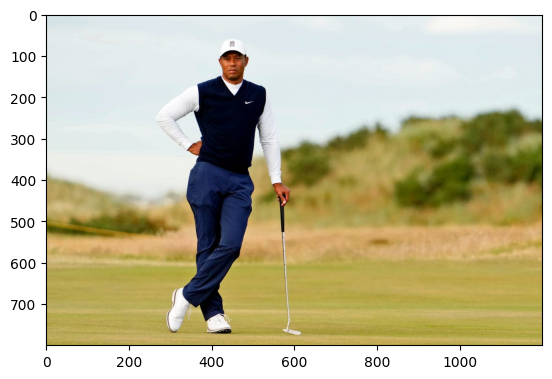

In [1]:
import numpy as np
from io import BytesIO
from PIL import Image
import matplotlib.pyplot as plt

from urllib.request import urlopen


url = 'https://i.ibb.co/gVQpNqF/imggolf.jpg'
img = np.array(Image.open(BytesIO(urlopen(url).read())), dtype=np.uint8)
# from google.colab.patches import cv2_imshow
# cv2_imshow(img[..., ::-1])
plt.imshow(img)